# 음성정보처리 기본 표현
## Overlap Add와 주파수 특성 및 표현
* 2026-10-06 수업

In [13]:
%pip install librosa matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import numpy as np
import scipy.signal as sps
import matplotlib as mpl
import matplotlib.pyplot as plt

import librosa
import librosa.display
from IPython.display import Audio, display

print("librosa 버전:", librosa.__version__)
print("numpy 버전:", np.__version__)

mpl.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False    # 마이너스 기호 깨짐 방지
mpl.rcParams["figure.figsize"] = (11, 3.5)
mpl.rcParams["figure.max_open_warning"] = 0
print("사용 폰트:", mpl.rcParams["font.family"])

librosa 버전: 1.0.0
numpy 버전: 2.5.3
사용 폰트: ['Malgun Gothic', 'DejaVu Sans']


In [15]:
# ── 오늘 사용할 음성 파일 ─────────────────────────────────────────────
# 방법 A: librosa 내장 예제 (영어 낭독 음성, 인터넷 필요)
# 방법 B: 직접 녹음한 wav 파일 경로를 AUDIO_PATH 에 적기  (권장! 자기 목소리가 제일 재미있습니다)
# 방법 C: 인터넷이 안 되면 맨 아래 [부록 A]의 합성 음성 코드를 먼저 실행

AUDIO_PATH = None          # 예: AUDIO_PATH = "my_voice.wav"
SR = 16000                 # 광대역 음성 표준

if AUDIO_PATH:
    y, sr = librosa.load(AUDIO_PATH, sr=SR, mono=True)
else:
    y, sr = librosa.load(librosa.example("libri1"), sr=SR, mono=True)

y = y[:int(4.0 * sr)]      # 너무 길면 앞 4초만 사용

print("y 타입      :", type(y))
print("y shape     :", y.shape, "  ← 샘플 개수")
print("y dtype     :", y.dtype, " ← 실수(float32), 보통 -1.0 ~ +1.0 범위")
print("sr          :", sr, "Hz")
print("길이        : %.2f 초" % librosa.get_duration(y=y, sr=sr))
print("샘플 수 검산: %d x %.2f = %.0f" % (sr, len(y)/sr, len(y)))
print("최대 진폭   : %.3f" % np.max(np.abs(y)))
print("\ny 의 앞 10개 값:", np.round(y[:10], 4))

y 타입      : <class 'numpy.ndarray'>
y shape     : (64000,)   ← 샘플 개수
y dtype     : float32  ← 실수(float32), 보통 -1.0 ~ +1.0 범위
sr          : 16000 Hz
길이        : 4.00 초
샘플 수 검산: 16000 x 4.00 = 64000
최대 진폭   : 0.779

y 의 앞 10개 값: [0.0003 0.0003 0.0002 0.0002 0.0001 0.0002 0.0001 0.0002 0.0001 0.0002]


In [16]:
# 들어보기 (Jupyter 전용 플레이어)
display(Audio(data=y, rate=sr))

## 켑스트럼, 포락(envelope), 고조파(harmonics) 분리

켑스트럼 피크 케프렌시 = 8.94 ms → F0 = 111.9 Hz


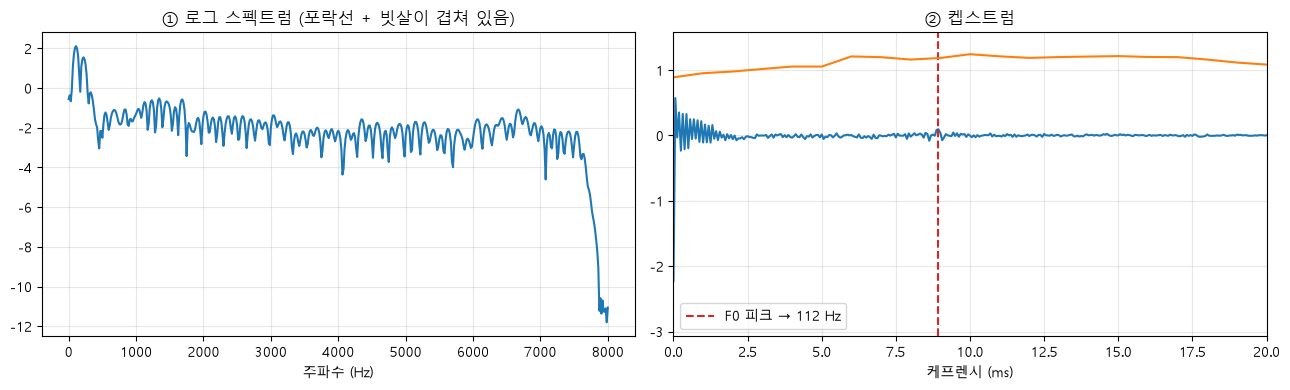

In [17]:
# 실습 3에서 선택하여 복사
FRAME_LEN = 400
HOP_LEN = 160

rms = librosa.feature.rms(
    y=y,
    frame_length=FRAME_LEN,
    hop_length=HOP_LEN
)[0]

zcr = librosa.feature.zero_crossing_rate(
    y,
    frame_length=FRAME_LEN,
    hop_length=HOP_LEN
)[0]

loud = rms > np.percentile(rms, 30)
voiced_idx = int(np.argmax(np.where(loud, -zcr, -9e9)))
seg_v = y[
    voiced_idx * HOP_LEN:
    voiced_idx * HOP_LEN + FRAME_LEN
]

# 켑스트럼 계산
NF = 1024
frame_v = seg_v * sps.get_window("hann", FRAME_LEN)

# ① DFT → ② 로그 크기 → ③ 역변환
spec = np.fft.rfft(frame_v, n=NF)
log_mag = np.log(np.abs(spec) + 1e-10)
cepstrum = np.fft.irfft(log_mag, n=NF)

quefrency_ms = np.arange(NF) / sr * 1000    # 케프렌시 축(ms)

# F0에 해당하는 케프렌시 피크 찾기 (2.5~14 ms ≈ 70~400 Hz)
q_lo, q_hi = int(sr/400), int(sr/70)
peak_q = q_lo + int(np.argmax(cepstrum[q_lo:q_hi]))

print(
    "켑스트럼 피크 케프렌시 = %.2f ms → F0 = %.1f Hz"
    % (peak_q/sr*1000, sr/peak_q)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.fft.rfftfreq(NF, 1/sr), log_mag)
axes[0].set(
    title="① 로그 스펙트럼 (포락선 + 빗살이 겹쳐 있음)",
    xlabel="주파수 (Hz)"
)

axes[1].plot(quefrency_ms[:NF//2], cepstrum[:NF//2])
axes[1].axvline(
    peak_q/sr*1000,
    color="C3",
    ls="--",
    label=f"F0 피크 → {sr/peak_q:.0f} Hz"
)
axes[1].plot(seg_v*10)

axes[1].set(
    title="② 켑스트럼",
    xlabel="케프렌시 (ms)",
    xlim=(0, 20)
)
axes[1].legend()

for a in axes:
    a.grid(alpha=.3)

plt.tight_layout()
plt.show()

### 포락과 고조파 분리

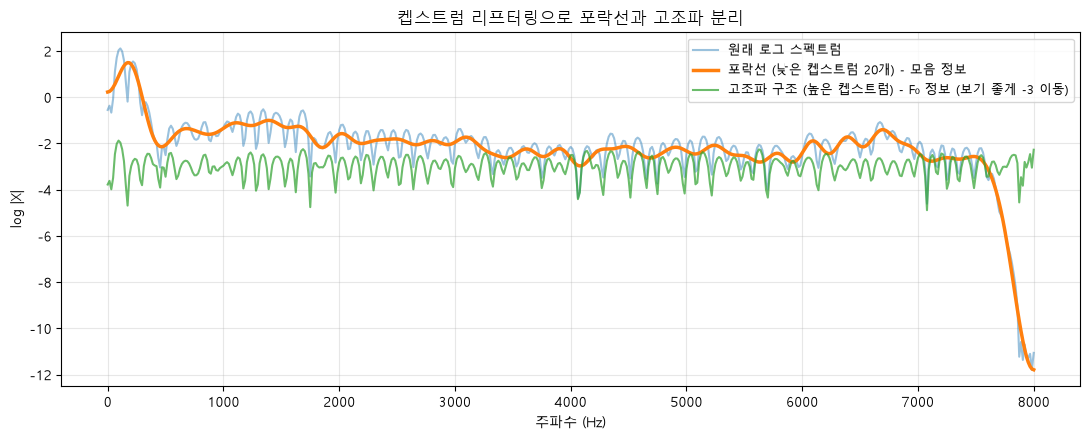

In [18]:
def lifter(cep, n_keep, mode="low"):
    # mode='low' → 낮은 케프렌시만 남김(포락선), 'high' → 높은 것만 남김(고조파)
    m = np.zeros_like(cep)
    if mode == "low":
        m[:n_keep] = 1
        m[-n_keep+1:] = 1
    else:
        m[n_keep:-n_keep+1] = 1
    return cep * m


LIFTER_PT = 60

env_log  = np.fft.rfft(lifter(cepstrum, LIFTER_PT, "low")).real   # 포락선만
fine_log = np.fft.rfft(lifter(cepstrum, LIFTER_PT, "high")).real  # 고조파 구조만
f_axis = np.fft.rfftfreq(NF, 1/sr)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(f_axis, log_mag, alpha=.45, label="원래 로그 스펙트럼")
ax.plot(f_axis, env_log, lw=2.5, label="포락선 (낮은 켑스트럼 20개) - 모음 정보")
ax.plot(f_axis, fine_log - 3, alpha=.7, label="고조파 구조 (높은 켑스트럼) - F₀ 정보 (보기 좋게 -3 이동)")
ax.set(title="켑스트럼 리프터링으로 포락선과 고조파 분리", xlabel="주파수 (Hz)", ylabel="log |X|")
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 멜 스케일, 멜 필터뱅크

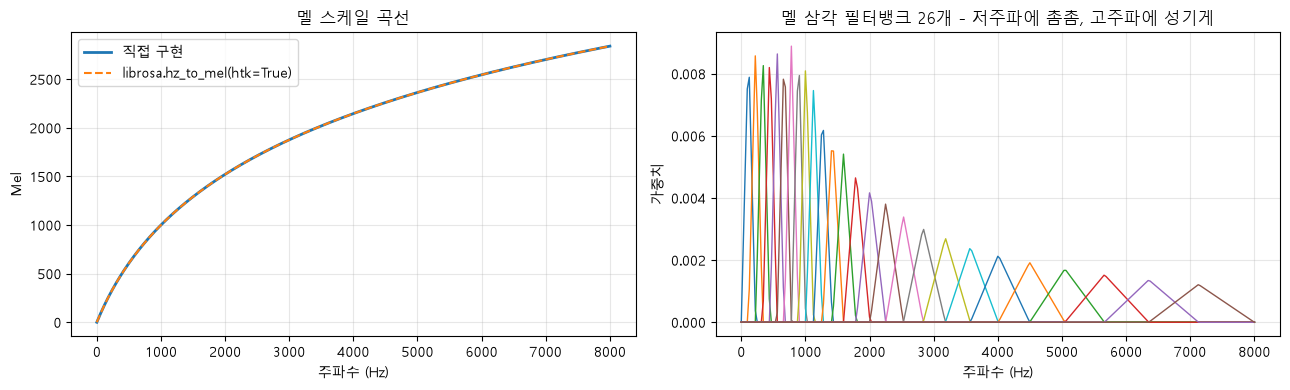

멜 필터뱅크 shape : (26, 257)  → (필터 개수, 주파수 bin 수)
1000 Hz → 1000.0 mel, 2000 Hz → 1521.4 mel  (두 배 주파수인데 멜은 두 배가 아님!)


In [19]:
sr = 16000  # 원래 음성의 sampling rate
N_FFT = 512  # fftp point (2^n)

f_hz = np.linspace(0, 8000, 400)
mel = 2595 * np.log10(1 + f_hz/700)              # 교재의 식 직접 구현
mel_librosa = librosa.hz_to_mel(f_hz, htk=True)  # librosa (htk=True가 같은 식)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(f_hz, mel, lw=2, label="직접 구현")
axes[0].plot(f_hz, mel_librosa, "--", label="librosa.hz_to_mel(htk=True)")
axes[0].set(title="멜 스케일 곡선", xlabel="주파수 (Hz)", ylabel="Mel"); axes[0].legend()

mel_fb = librosa.filters.mel(sr=sr, n_fft=N_FFT, n_mels=26)  # (26, 257)
for i in range(mel_fb.shape[0]):
    axes[1].plot(librosa.fft_frequencies(sr=sr, n_fft=N_FFT), mel_fb[i], lw=1)
axes[1].set(title="멜 삼각 필터뱅크 26개 - 저주파에 촘촘, 고주파에 성기게",
            xlabel="주파수 (Hz)", ylabel="가중치")
for a in axes: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("멜 필터뱅크 shape :", mel_fb.shape, " → (필터 개수, 주파수 bin 수)")
print("1000 Hz → %.1f mel, 2000 Hz → %.1f mel  (두 배 주파수인데 멜은 두 배가 아님!)"
      % (librosa.hz_to_mel(1000, htk=True), librosa.hz_to_mel(2000, htk=True)))

### MFCC

일반 스펙트로그램  : (257, 401)  -> 프레임당 257개 계수
멜 스펙트로그램    : (40, 401)  -> 프레임당 40개 계수 (대폭 압축)


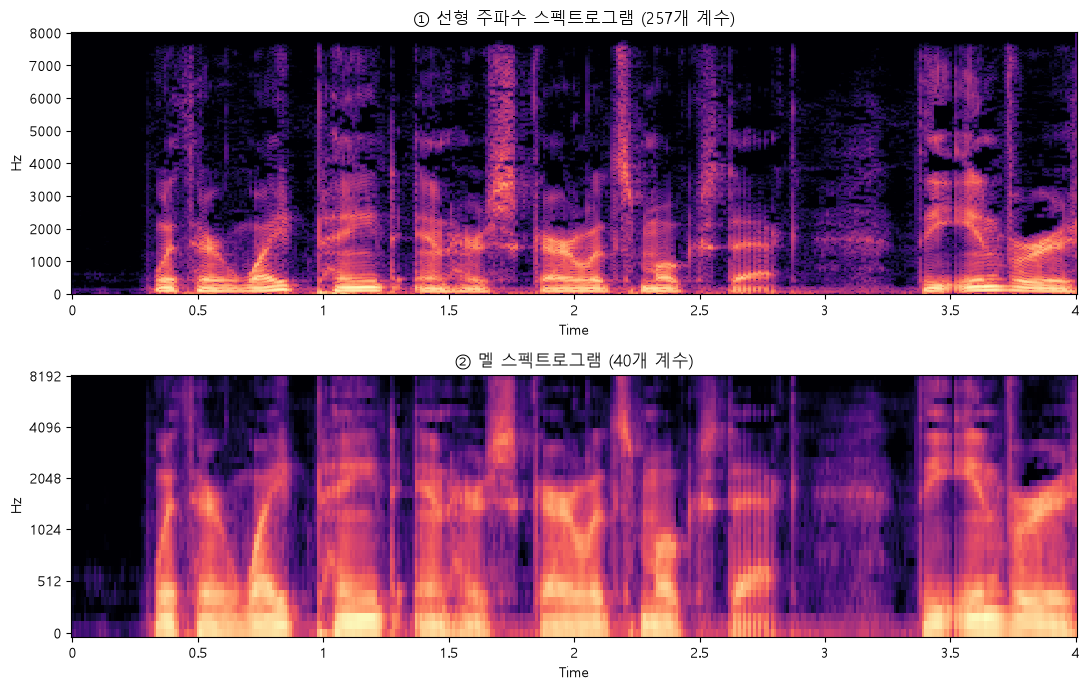

In [20]:
def show_spec(D_complex, sr, hop_length, title, y_axis="hz", ax=None, fmax=None):
    S_db = librosa.amplitude_to_db(np.abs(D_complex), ref=np.max)
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(11, 4))
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length,
                                   x_axis="time", y_axis=y_axis, ax=ax, cmap="magma")
    if fmax:
        ax.set_ylim(0, fmax)
    ax.set(title=title)
    if created:
        ax.figure.colorbar(img, ax=ax, format="%+2.0f dB")
        plt.tight_layout(); plt.show()
    return img


# 멜 스펙트로그램 = 멜 필터뱅크를 전력 스펙트로그램에 곱한 것
S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT,
                                       hop_length=HOP_LEN, win_length=FRAME_LEN, n_mels=40)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)
D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LEN, win_length=FRAME_LEN, window="hann")

print("일반 스펙트로그램  :", D.shape, " -> 프레임당 %d개 계수" % D.shape[0])
print("멜 스펙트로그램    :", S_mel.shape, " -> 프레임당 %d개 계수 (대폭 압축)" % S_mel.shape[0])

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
show_spec(D, sr, HOP_LEN, "① 선형 주파수 스펙트로그램 (257개 계수)", ax=axes[0])

img = librosa.display.specshow(S_mel_db, sr=sr, hop_length=HOP_LEN,
                               x_axis="time", y_axis="mel", ax=axes[1], cmap="magma")
axes[1].set(title="② 멜 스펙트로그램 (40개 계수)")
plt.tight_layout(); plt.show()

In [21]:
n_mfcc = 13
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=N_FFT,
                            hop_length=HOP_LEN, win_length=FRAME_LEN, n_mels=40)
print("MFCC shape :", mfcc.shape, " -> (계수 13개, 프레임 수)")

# librosa가 내부에서 하는 일을 직접 따라해 보기 (멜 로그 스펙트럼 → DCT)
from scipy.fftpack import dct
mfcc_manual = dct(librosa.power_to_db(S_mel), axis=0, type=2, norm="ortho")[:n_mfcc]
print("직접 구현과 librosa 결과의 최대 차이: %.2e -> 같은 계산입니다" %
      np.max(np.abs(mfcc - mfcc_manual)))

MFCC shape : (13, 401)  -> (계수 13개, 프레임 수)
직접 구현과 librosa 결과의 최대 차이: 0.00e+00 -> 같은 계산입니다


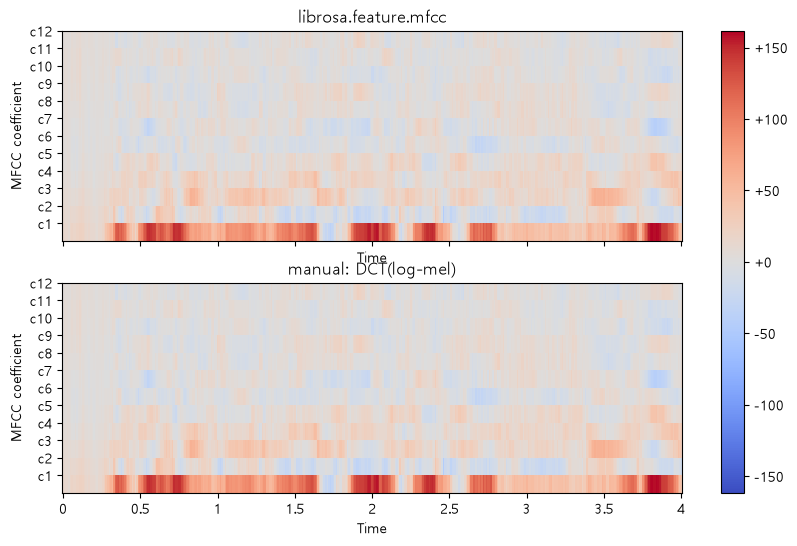

In [22]:
vmax = np.max(np.abs(mfcc[1:]))
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax, M, title in zip(
    axes,
    [mfcc, mfcc_manual],
    ["librosa.feature.mfcc", "manual: DCT(log-mel)"]
):
    img = librosa.display.specshow(
        M[1:],
        x_axis="time",
        sr=sr,
        hop_length=HOP_LEN,
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        ax=ax
    )
    ax.set_yticks(np.arange(n_mfcc - 1) + 0.5)
    ax.set_yticklabels([f"c{i}" for i in range(1, n_mfcc)])
    ax.set_title(title)
    ax.set_ylabel("MFCC coefficient")

fig.colorbar(img, ax=axes, format="%+.0f")
plt.show()